In [1]:

!pip install -q qiskit qiskit-aer matplotlib

!pip install pylatexenc matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=c853a4cc826dddda83fec14c6ee53441951dc2e9e0326f3f60e9d46569f64280
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


Quantum Circuit Diagram:


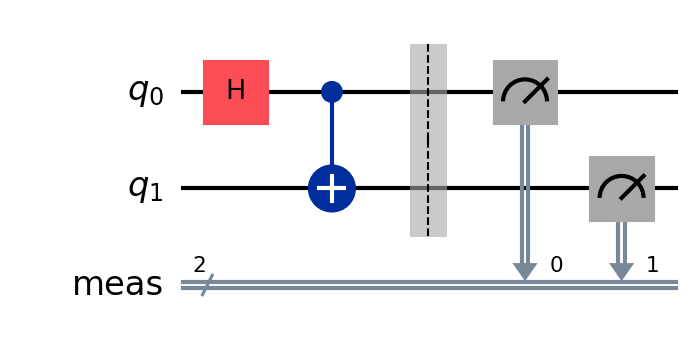


Simulation Result: {'11': 524, '00': 500}


In [2]:
# --- Auto-install required libraries (safe for Colab) ---
!pip install qiskit qiskit-aer pylatexenc matplotlib --quiet

# --- Imports ---
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from PIL import Image

# --- Create a simulator backend ---
backend = AerSimulator()

# --- Define a simple quantum circuit ---
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

# --- Transpile the circuit ---
tqc = transpile(qc, backend)

# --- Run the simulation ---
job = backend.run(tqc, shots=1024)
result = job.result()
counts = result.get_counts()

# --- Draw and save circuit as a colored image ---
try:
    qc.draw(output='mpl', filename='simple_circuit.png')
    print("Quantum Circuit Diagram:")
    display(Image.open('simple_circuit.png'))
except Exception as e:
    print("Matplotlib drawer failed — trying text mode instead.")
    print(qc.draw(output='text'))

# --- Simulation result ---
print("\nSimulation Result:", counts)


In [3]:

def expectation_z(theta, phi, shots=8192):
    """Return ⟨Z⟩ for |ψ⟩ = RY(phi) RX(theta) |0⟩"""
    qc = QuantumCircuit(1)
    qc.rx(theta, 0)
    qc.ry(phi, 0)
    qc.measure_all()

    tqc = transpile(qc, backend)
    job = backend.run(tqc, shots=shots)
    result = job.result()
    counts = result.get_counts()

    # Expectation of Z = P(0) − P(1)
    p0 = counts.get('0', 0) / shots
    p1 = counts.get('1', 0) / shots
    return p0 - p1


def cost(theta, phi):
    """Cost function C(θ,φ)=⟨Z⟩"""
    return expectation_z(theta, phi)


In [6]:
import numpy as np
def param_shift_grad(theta, phi, shift=np.pi/2):
    """Compute ∂C/∂θ and ∂C/∂φ via the parameter-shift rule."""
    dtheta = 0.5 * (expectation_z(theta + shift, phi) - expectation_z(theta - shift, phi))
    dphi   = 0.5 * (expectation_z(theta, phi + shift) - expectation_z(theta, phi - shift))
    return np.array([dtheta, dphi])


In [7]:

eta = 0.3          # learning rate
steps = 10         # number of iterations
np.random.seed(42) # reproducible randomness
theta, phi = np.random.uniform(0, 2*np.pi, 2)

theta_hist, phi_hist, cost_hist = [], [], []

print("Step |   θ(rad)   |   φ(rad)   |   Cost=<Z>   |   ∂θC   |   ∂φC")
print("---------------------------------------------------------------")

for step in range(steps):
    c = cost(theta, phi)
    grad = param_shift_grad(theta, phi)
    theta -= eta * grad[0]
    phi   -= eta * grad[1]

    theta_hist.append(theta)
    phi_hist.append(phi)
    cost_hist.append(c)

    print(f"{step:4d} | {theta:9.5f} | {phi:9.5f} | {c:11.6f} | {grad[0]:7.4f} | {grad[1]:7.4f}")

print("\nFinal θ, φ:", theta, phi)
print("Final cost (expectation <Z>):", cost(theta, phi))


Step |   θ(rad)   |   φ(rad)   |   Cost=<Z>   |   ∂θC   |   ∂φC
---------------------------------------------------------------
   0 |   2.55249 |   6.03130 |   -0.673096 | -0.6639 | -0.1926
   1 |   2.71615 |   6.09385 |   -0.805176 | -0.5455 | -0.2085
   2 |   2.83853 |   6.14853 |   -0.903076 | -0.4080 | -0.1823
   3 |   2.92675 |   6.18178 |   -0.946533 | -0.2941 | -0.1108
   4 |   2.99260 |   6.20910 |   -0.972900 | -0.2195 | -0.0911
   5 |   3.03940 |   6.23074 |   -0.985107 | -0.1560 | -0.0721
   6 |   3.07331 |   6.24645 |   -0.995117 | -0.1130 | -0.0524
   7 |   3.09609 |   6.25421 |   -0.997559 | -0.0759 | -0.0259
   8 |   3.11008 |   6.26132 |   -0.998779 | -0.0466 | -0.0237
   9 |   3.12011 |   6.26652 |   -0.999512 | -0.0334 | -0.0173

Final θ, φ: 3.1201140537222942 6.266519532453967
Final cost (expectation <Z>): -0.9990234375


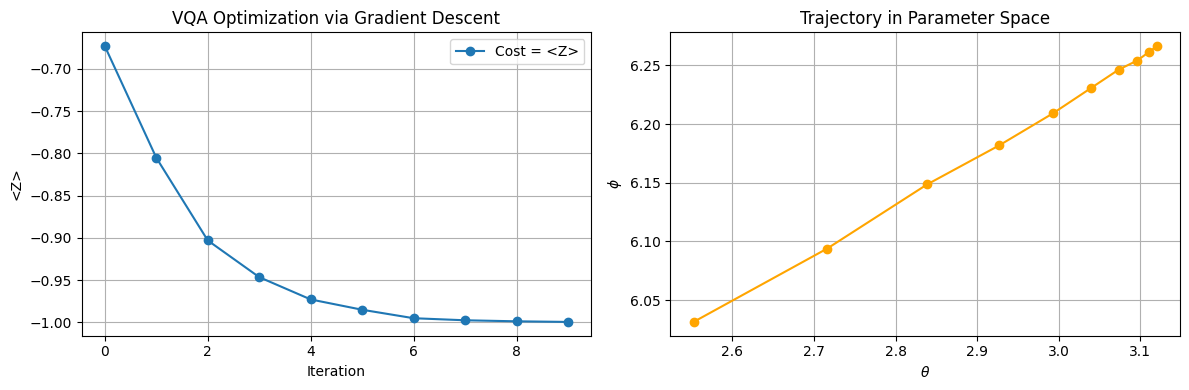

In [9]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12,4))

axs[0].plot(cost_hist, 'o-', label='Cost = <Z>')
axs[0].set_xlabel('Iteration')
axs[0].set_ylabel('<Z>')
axs[0].set_title('VQA Optimization via Gradient Descent')
axs[0].grid(True)
axs[0].legend()

axs[1].plot(theta_hist, phi_hist, 'o-', color='orange')
axs[1].set_xlabel(r'$\theta$')
axs[1].set_ylabel(r'$\phi$')
axs[1].set_title('Trajectory in Parameter Space')
axs[1].grid(True)

plt.tight_layout()
plt.show()
